<a href="https://colab.research.google.com/github/Mansehaj-Singh/Drone-Orientation-Estimation/blob/main/QGD_OE_IMU_Medium.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving AP1.xlsx to AP1.xlsx
Saving AP2.xlsx to AP2.xlsx
Saving Qs_medium.xlsx to Qs_medium.xlsx
Saving SH1.xlsx to SH1.xlsx
Saving SH2.xlsx to SH2.xlsx
Saving XS1.xlsx to XS1.xlsx
Saving XS2.xlsx to XS2.xlsx


In [2]:
!pip install openpyxl -q

Using device: cuda
Processing: XS1.xlsx
Created 20062 sequences
Processing: XS2.xlsx
Total sequences: 20062
Static sequences: 12534
Dynamic sequences: 7528
Train shape: (16049, 200, 6)
Test shape: (4013, 200, 6)
Epoch 1/25 Loss: 0.2194
Epoch 2/25 Loss: 0.1321
Epoch 3/25 Loss: 0.0965
Epoch 4/25 Loss: 0.0802
Epoch 5/25 Loss: 0.0670
Epoch 6/25 Loss: 0.0760
Epoch 7/25 Loss: 0.0987
Epoch 8/25 Loss: 0.0552
Epoch 9/25 Loss: 0.0430
Epoch 10/25 Loss: 0.0409
Epoch 11/25 Loss: 0.0422
Epoch 12/25 Loss: 0.0631
Epoch 13/25 Loss: 0.0413
Epoch 14/25 Loss: 0.0450
Epoch 15/25 Loss: 0.0490
Epoch 16/25 Loss: 0.0390
Epoch 17/25 Loss: 0.0329
Epoch 18/25 Loss: 0.0355
Epoch 19/25 Loss: 0.0261
Epoch 20/25 Loss: 0.0242
Epoch 21/25 Loss: 0.0209
Epoch 22/25 Loss: 0.0199
Epoch 23/25 Loss: 0.0184
Epoch 24/25 Loss: 0.0178
Epoch 25/25 Loss: 0.0179


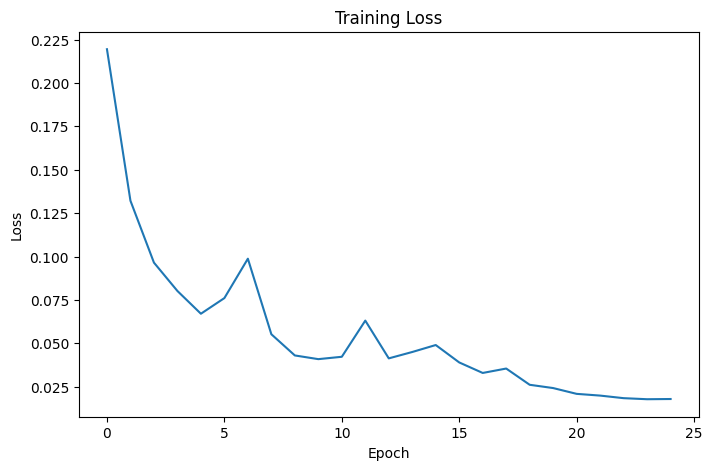


FINAL RESULTS
RMSE qw: 0.04333874
RMSE qx: 0.016636258
RMSE qy: 0.009020227
RMSE qz: 0.03215225
Mean RMSE: 0.025286868
Mean Orientation Error: 1.768766
Median Orientation Error: 0.19782342
mAP@0.5: 0.6002990281584849
mAP@0.5:0.95: 0.6260652878146026
Saved predictions.csv


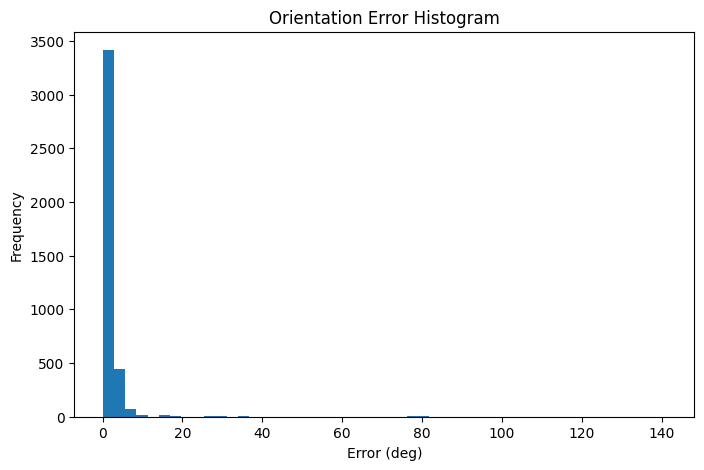

Convergence Times: [40.13, 40.13, 40.13, 40.13]
Mean Convergence Time: 40.13
Saved convergence_results.csv


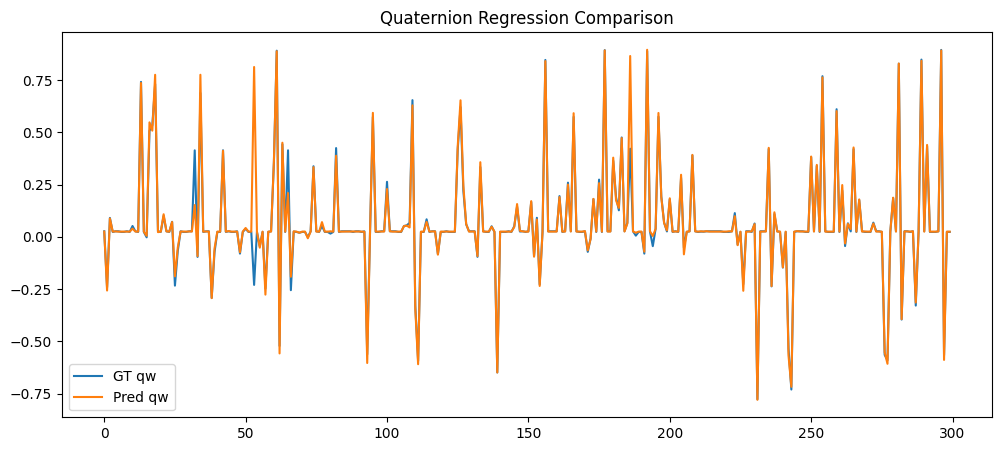


FINAL METRIC TABLE
                     Metric      Value
0                   RMSE_qw   0.043339
1                   RMSE_qx   0.016636
2                   RMSE_qy   0.009020
3                   RMSE_qz   0.032152
4                 Mean_RMSE   0.025287
5    Mean_Orientation_Error   1.768766
6  Median_Orientation_Error   0.197823
7                     mAP50   0.600299
8                  mAP50_95   0.626065
9     Mean_Convergence_Time  40.130000
Saved architecture_comparison_results.csv

DONE


In [3]:


import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import signal

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ==========================================================
# CONFIG
# ==========================================================

SENSOR_FILES = [
    'XS1.xlsx',
    'XS2.xlsx',
    'AP1.xlsx',
    'AP2.xlsx',
    'SH1.xlsx',
    'SH2.xlsx'
]

QUAT_FILE = 'Qs_medium.xlsx'

SEQ_LEN = 200
MOTION_THRESHOLD = 0.1

BATCH_SIZE = 64
EPOCHS = 25
LR = 1e-3

RANDOM_STATE = 42

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('Using device:', DEVICE)

# ==========================================================
# HELPERS
# ==========================================================

def normalize_quaternions(q):

    q = q.astype(np.float32)

    n = np.linalg.norm(q, axis=1, keepdims=True)

    n = np.where(n == 0, 1.0, n)

    return q / n


def read_sensor_excel(path):

    df = pd.read_excel(path)

    if df.shape[1] < 14:
        raise ValueError(f'{path} has insufficient columns')

    df = df.iloc[:, :14].copy()

    df.columns = [
        'time',
        'ax','ay','az',
        'gx','gy','gz',
        'mx','my','mz',
        'ox','oy','oz','ow'
    ]

    return df


# ==========================================================
# SEQUENCE CREATION
# ==========================================================

def create_sequences(X, y, motion, seq_len=200):

    X_seq = []
    y_seq = []
    m_seq = []

    n = len(X)

    if n < seq_len:
        return (
            np.empty((0, seq_len, X.shape[1]), dtype=np.float32),
            np.empty((0, y.shape[1]), dtype=np.float32),
            np.empty((0,), dtype=np.int64)
        )

    for i in range(n - seq_len + 1):

        j = i + seq_len

        X_seq.append(X[i:j])

        y_seq.append(y[j - 1])

        if np.mean(motion[i:j]) > 0.5:
            m_seq.append(1)
        else:
            m_seq.append(0)

    return (
        np.asarray(X_seq, dtype=np.float32),
        np.asarray(y_seq, dtype=np.float32),
        np.asarray(m_seq, dtype=np.int64)
    )


# ==========================================================
# STATIC / DYNAMIC SPLIT
# ==========================================================

def balanced_sequence_split(X, y, motion):

    static_mask = motion == 0
    dynamic_mask = motion == 1

    X_static = X[static_mask]
    y_static = y[static_mask]

    X_dynamic = X[dynamic_mask]
    y_dynamic = y[dynamic_mask]

    print('Static sequences:', len(X_static))
    print('Dynamic sequences:', len(X_dynamic))

    def split_subset(Xs, ys):

        if len(Xs) < 2:
            return Xs, Xs[:0], ys, ys[:0]

        Xtr, Xte, ytr, yte = train_test_split(
            Xs,
            ys,
            test_size=0.2,
            random_state=RANDOM_STATE,
            shuffle=True
        )

        return Xtr, Xte, ytr, yte

    Xs_tr, Xs_te, ys_tr, ys_te = split_subset(X_static, y_static)

    Xd_tr, Xd_te, yd_tr, yd_te = split_subset(X_dynamic, y_dynamic)

    if len(Xs_tr) and len(Xd_tr):
        X_train = np.concatenate([Xs_tr, Xd_tr], axis=0)
        y_train = np.concatenate([ys_tr, yd_tr], axis=0)
    else:
        X_train = Xs_tr if len(Xd_tr) == 0 else Xd_tr
        y_train = ys_tr if len(yd_tr) == 0 else yd_tr

    if len(Xs_te) and len(Xd_te):
        X_test = np.concatenate([Xs_te, Xd_te], axis=0)
        y_test = np.concatenate([ys_te, yd_te], axis=0)
    else:
        X_test = Xs_te if len(Xd_te) == 0 else Xd_te
        y_test = ys_te if len(yd_te) == 0 else yd_te

    tr_idx = np.random.permutation(len(X_train))
    te_idx = np.random.permutation(len(X_test))

    X_train = X_train[tr_idx]
    y_train = y_train[tr_idx]

    X_test = X_test[te_idx]
    y_test = y_test[te_idx]

    return X_train, X_test, y_train, y_test


# ==========================================================
# SCALING
# ==========================================================

def fit_transform_sequences(X_train, X_test):

    scaler = StandardScaler()

    n_tr, t_tr, c = X_train.shape
    n_te, t_te, _ = X_test.shape

    X_train_2d = X_train.reshape(-1, c)
    X_test_2d = X_test.reshape(-1, c)

    X_train_scaled = scaler.fit_transform(X_train_2d)
    X_test_scaled = scaler.transform(X_test_2d)

    X_train_scaled = X_train_scaled.reshape(n_tr, t_tr, c)
    X_test_scaled = X_test_scaled.reshape(n_te, t_te, c)

    return X_train_scaled, X_test_scaled


# ==========================================================
# QUATERNION METRICS
# ==========================================================

def quaternion_geodesic_loss(pred, target):

    pred = F.normalize(pred, p=2, dim=1)
    target = F.normalize(target, p=2, dim=1)

    dot = torch.abs(torch.sum(pred * target, dim=1))

    dot = torch.clamp(dot, -1.0 + 1e-7, 1.0 - 1e-7)

    angle = 2.0 * torch.acos(dot)

    return angle.mean()


def quaternion_rmse(pred, target):

    return np.sqrt(np.mean((pred - target) ** 2, axis=0))


def quaternion_angle_error_deg(pred, target):

    pred = pred / np.linalg.norm(pred, axis=1, keepdims=True)
    target = target / np.linalg.norm(target, axis=1, keepdims=True)

    dots = np.abs(np.sum(pred * target, axis=1))

    dots = np.clip(dots, -1.0, 1.0)

    angles = 2.0 * np.degrees(np.arccos(dots))

    return angles


# ==========================================================
# DATA PREPARATION
# ==========================================================

quat_df = pd.read_excel(QUAT_FILE)

quat_df = quat_df.iloc[:, :4].copy()

quat_df.columns = ['qw','qx','qy','qz']

quat_all = normalize_quaternions(
    quat_df.to_numpy(np.float32)
)

quat_offset = 0

X_seq_all = []
y_seq_all = []
m_seq_all = []

for fname in SENSOR_FILES:

    print('Processing:', fname)

    df = read_sensor_excel(fname)

    n_available = len(quat_all) - quat_offset

    if n_available <= 0:
        break

    n = min(len(df), n_available)

    df = df.iloc[:n].reset_index(drop=True)

    quat_slice = quat_all[quat_offset:quat_offset+n]

    quat_offset += n

    motion = (
        np.sqrt(
            df['gx'].to_numpy()**2 +
            df['gy'].to_numpy()**2 +
            df['gz'].to_numpy()**2
        ) > MOTION_THRESHOLD
    ).astype(np.int64)

    X_raw = df[
        ['ax','ay','az','gx','gy','gz']
    ].to_numpy(np.float32)

    y_raw = quat_slice.astype(np.float32)

    Xs, ys, ms = create_sequences(
        X_raw,
        y_raw,
        motion,
        seq_len=SEQ_LEN
    )

    # FIXED EMPTY ARRAY ISSUE
    if len(Xs) > 0:

        print(f'Created {len(Xs)} sequences')

        X_seq_all.append(Xs)
        y_seq_all.append(ys)
        m_seq_all.append(ms)

    else:

        print(f'Skipping {fname} because no sequences created')

if len(X_seq_all) == 0:
    raise RuntimeError('No valid sequences were created.')

X_seq = np.concatenate(X_seq_all, axis=0)
y_seq = np.concatenate(y_seq_all, axis=0)
m_seq = np.concatenate(m_seq_all, axis=0)

print('Total sequences:', len(X_seq))

X_train, X_test, y_train, y_test = balanced_sequence_split(
    X_seq,
    y_seq,
    m_seq
)

X_train, X_test = fit_transform_sequences(
    X_train,
    X_test
)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)

# ==========================================================
# DATASET
# ==========================================================

class IMUDataset(Dataset):

    def __init__(self, X, y):

        self.X = X.astype(np.float32)
        self.y = y.astype(np.float32)

    def __len__(self):

        return len(self.X)

    def __getitem__(self, idx):

        x = torch.tensor(
            self.X[idx].T,
            dtype=torch.float32
        )

        y = torch.tensor(
            self.y[idx],
            dtype=torch.float32
        )

        return x, y


train_loader = DataLoader(
    IMUDataset(X_train, y_train),
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    IMUDataset(X_test, y_test),
    batch_size=BATCH_SIZE,
    shuffle=False
)

# ==========================================================
# MODEL
# ==========================================================

class CNNBiLSTM(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv1 = nn.Conv1d(6,64,5,padding=2)
        self.conv2 = nn.Conv1d(64,128,5,padding=2)

        self.lstm = nn.LSTM(
            input_size=128,
            hidden_size=128,
            num_layers=2,
            batch_first=True,
            bidirectional=True
        )

        self.fc1 = nn.Linear(256,128)
        self.fc2 = nn.Linear(128,4)

    def forward(self, x):

        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))

        x = x.permute(0,2,1)

        x,_ = self.lstm(x)

        x = x[:,-1,:]

        x = F.relu(self.fc1(x))

        x = self.fc2(x)

        return F.normalize(x, p=2, dim=1)


model = CNNBiLSTM().to(DEVICE)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LR
)

# ==========================================================
# TRAINING
# ==========================================================

train_losses = []

for epoch in range(EPOCHS):

    model.train()

    total_loss = 0

    for xb, yb in train_loader:

        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        optimizer.zero_grad()

        pred = model(xb)

        loss = quaternion_geodesic_loss(
            pred,
            yb
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    train_losses.append(avg_loss)

    print(
        f'Epoch {epoch+1}/{EPOCHS} '
        f'Loss: {avg_loss:.4f}'
    )

# ==========================================================
# LOSS CURVE
# ==========================================================

plt.figure(figsize=(8,5))

plt.plot(train_losses)

plt.title('Training Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.show()

# ==========================================================
# EVALUATION
# ==========================================================

model.eval()

preds = []
gts = []

with torch.no_grad():

    for xb, yb in test_loader:

        xb = xb.to(DEVICE)

        pred = model(xb)

        preds.append(pred.cpu().numpy())
        gts.append(yb.numpy())

preds = np.concatenate(preds)
gts = np.concatenate(gts)

# ==========================================================
# RMSE
# ==========================================================

rmse_components = quaternion_rmse(
    preds,
    gts
)

mean_component_rmse = np.mean(
    rmse_components
)

# ==========================================================
# ORIENTATION ERROR
# ==========================================================

orientation_errors = quaternion_angle_error_deg(
    preds,
    gts
)

mean_orientation_error = np.mean(
    orientation_errors
)

median_orientation_error = np.median(
    orientation_errors
)

# ==========================================================
# mAP PROXY
# ==========================================================

map50 = np.mean(
    orientation_errors < 0.5
)

thresholds = np.arange(0.5,1.0,0.05)

ap_scores = []

for t in thresholds:

    ap_scores.append(
        np.mean(orientation_errors < t)
    )

map5095 = np.mean(ap_scores)

# ==========================================================
# PRINT METRICS
# ==========================================================

print('\n===============================')
print('FINAL RESULTS')
print('===============================')

print('RMSE qw:', rmse_components[0])
print('RMSE qx:', rmse_components[1])
print('RMSE qy:', rmse_components[2])
print('RMSE qz:', rmse_components[3])

print('Mean RMSE:', mean_component_rmse)

print('Mean Orientation Error:',
      mean_orientation_error)

print('Median Orientation Error:',
      median_orientation_error)

print('mAP@0.5:', map50)

print('mAP@0.5:0.95:', map5095)

# ==========================================================
# CSV EXPORT
# ==========================================================

prediction_df = pd.DataFrame({

    'gt_qw': gts[:,0],
    'gt_qx': gts[:,1],
    'gt_qy': gts[:,2],
    'gt_qz': gts[:,3],

    'pred_qw': preds[:,0],
    'pred_qx': preds[:,1],
    'pred_qy': preds[:,2],
    'pred_qz': preds[:,3],

    'orientation_error_deg':
        orientation_errors
})

prediction_df.to_csv(
    'predictions.csv',
    index=False
)

print('Saved predictions.csv')

# ==========================================================
# HISTOGRAM
# ==========================================================

plt.figure(figsize=(8,5))

plt.hist(
    orientation_errors,
    bins=50
)

plt.title(
    'Orientation Error Histogram'
)

plt.xlabel('Error (deg)')

plt.ylabel('Frequency')

plt.show()

# ==========================================================
# CONVERGENCE ANALYSIS
# ==========================================================

filter_size = 10

a = np.ones(1)

b = np.ones(filter_size + 1)

b /= filter_size + 1

diff = np.zeros(
    (len(preds),4),
    dtype=np.float64
)

for j in range(4):

    diff[:,j] = (
        preds[:,j] - gts[:,j]
    )

diff = diff * diff

diff_filtered = np.zeros_like(diff)

for j in range(diff.shape[1]):

    diff_filtered[:,j] = signal.lfilter(
        b,
        a,
        diff[:,j]
    )

    diff_filtered[:,j] /= filter_size

    diff_filtered[:,j] = np.sqrt(
        diff_filtered[:,j]
    )

convergence_threshold = 0.125

convergence_times = []

for j in range(diff_filtered.shape[1]):

    convergence_time = (
        len(diff_filtered) * 0.01
    )

    for i in reversed(
        range(diff_filtered.shape[0])
    ):

        if diff_filtered[i,j] > convergence_threshold:

            convergence_time = round(
                float(i)*0.01,
                2
            )

            break

    convergence_times.append(
        convergence_time
    )

mean_convergence_time = np.mean(
    convergence_times
)

print('Convergence Times:',
      convergence_times)

print('Mean Convergence Time:',
      mean_convergence_time)

# ==========================================================
# CONVERGENCE CSV
# ==========================================================

conv_df = pd.DataFrame({

    'Component':
        ['qw','qx','qy','qz'],

    'Convergence_Time':
        convergence_times
})

conv_df.to_csv(
    'convergence_results.csv',
    index=False
)

print('Saved convergence_results.csv')

# ==========================================================
# QUATERNION PLOT
# ==========================================================

plt.figure(figsize=(12,5))

plt.plot(
    gts[:300,0],
    label='GT qw'
)

plt.plot(
    preds[:300,0],
    label='Pred qw'
)

plt.legend()

plt.title(
    'Quaternion Regression Comparison'
)

plt.show()

# ==========================================================
# FINAL COMPARISON TABLE
# ==========================================================

results_df = pd.DataFrame({

    'Metric': [

        'RMSE_qw',
        'RMSE_qx',
        'RMSE_qy',
        'RMSE_qz',
        'Mean_RMSE',
        'Mean_Orientation_Error',
        'Median_Orientation_Error',
        'mAP50',
        'mAP50_95',
        'Mean_Convergence_Time'
    ],

    'Value': [

        rmse_components[0],
        rmse_components[1],
        rmse_components[2],
        rmse_components[3],
        mean_component_rmse,
        mean_orientation_error,
        median_orientation_error,
        map50,
        map5095,
        mean_convergence_time
    ]
})

print('\nFINAL METRIC TABLE')

print(results_df)

results_df.to_csv(
    'architecture_comparison_results.csv',
    index=False
)

print(
    'Saved architecture_comparison_results.csv'
)

print('\nDONE')